# Fatigue regression

Regression models for `fatigue_num` (0–5): continuous loss, then round and clip.
Same participant split and baselines as notebook 3; classification models
are in [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb) only.

Core logic lives in `src/modeling/`. Uses **20 daily features** (15 numeric + 5 categorical from `FEATURE_COLUMNS`, including mcPHASES `daily_glucose`, `daily_hrv`, `sleep_score` from the processed CSV). Tree models one-hot encode `phase` to 23 columns.


In [120]:
%pip install -q -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
import sys
from pathlib import Path

_src = Path('../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# Ensure local src edits are picked up when re-running this cell.
for _mod in [k for k in list(sys.modules) if k == 'modeling' or k.startswith('modeling.')]:
    del sys.modules[_mod]

import pandas as pd
from modeling.baselines import (
    run_all_baseline_benchmarks,
    summarize_baseline_metrics,
)
from modeling.calibration import (
    DISCRETIZATION_DOCS,
    RINT_CLIP_MODELS,
    benchmark_cutpoint_calibration,
    cutpoints_differ_from_default,
)
from modeling.config import (
    DATA_PATH,
    CUTPOINT_ALTERNATING_ITERATIONS,
    ELASTICNET_OPTUNA_TRIALS,
    N_CV_FOLDS,
    OPTUNA_TRIALS,
    SVR_OPTUNA_TRIALS,
    TIME_COL,
    TIME_SERIES_GROUP_COLS,
)
from modeling.data import (
    build_split_bundle,
    load_fatigue_data,
    participant_strata,
    preprocess_after_split,
    split_participant_ids,
    split_summary_table,
)
from modeling.registry import ORDINAL_MODELS
from modeling.runner import (
    plot_cutpoint_iteration_mae,
    print_cutpoint_comparison,
    print_cutpoint_iteration_table,
    print_ordinal_rf_ablation_importance,
    print_ordinal_rf_gini_importance,
    print_ordinal_test_prediction_diagnostic,
    run_cutpoint_alternating_iterations,
    print_tune_summary,
    tune_and_benchmark_model,
)
from modeling.summaries import (
    CATEGORY_ORDER,
    collect_categorized_summaries,
)


## 1. Load data and split

Participants are held out with a **stratified split** on per-participant **mean fatigue** (`fatigue_num` averaged over each participant's days) so train/val and test have similar average fatigue levels.

“We randomly assign whole participants to train/val or test, but we do it in a way that both groups contain a similar mix of people with low, medium, and high average fatigue — not just a random 8 people who might all happen to be high-average-fatigue reporters.”

**Post-split preprocessing:** NaNs in `menstrual_health_literacy_num` and `daily_hrv` are filled with the **train/val median only** via `preprocess_after_split()` — test participants never contribute to that statistic.


In [122]:
df = load_fatigue_data('../../' + DATA_PATH)
df = df.sort_values(TIME_SERIES_GROUP_COLS + [TIME_COL]).reset_index(drop=True)

strata = participant_strata(df)
train_val_ids, test_ids = split_participant_ids(df['id'].unique(), strata=strata)
train_val_mask = df['id'].isin(train_val_ids)
test_mask = df['id'].isin(test_ids)

literacy_col = 'menstrual_health_literacy_num'
print(f'Literacy NaNs before preprocess: {df[literacy_col].isna().sum()}')
df = preprocess_after_split(df, train_val_mask)
print(f'Literacy NaNs after preprocess: {df[literacy_col].isna().sum()}')

bundle = build_split_bundle(df, train_val_ids, test_ids, train_val_mask, test_mask)

print(f"Rows: {len(df):,}  Participants: {df['id'].nunique()}")
display(split_summary_table(bundle))
print('Test participant ids:', sorted(bundle.test_ids))


Literacy NaNs before preprocess: 80
Literacy NaNs after preprocess: 0
Rows: 3,331  Participants: 42


,split,participants,rows,mean_fatigue
0,train_val,34,2659,2.462204
1,test,8,672,2.653274


Test participant ids: [np.int64(7), np.int64(14), np.int64(24), np.int64(38), np.int64(40), np.int64(41), np.int64(46), np.int64(50)]


Re-run the **init accumulators** cell below before a fresh partial run to clear prior tuned-model results.


In [123]:
# Re-run this cell to clear accumulated model results before a fresh partial run.
ordinal_results = []
ordinal_best_params = {}


## 2. Baseline benchmarks

Simple predictors evaluated with the same GroupKFold CV and held-out test protocol as the tuned models. Includes persistence baselines **`lag1_fatigue`** and **`expanding_mean`**.


In [124]:
ordinal_baseline_results = run_all_baseline_benchmarks(bundle, n_splits=N_CV_FOLDS)

ordinal_baseline_summary = summarize_baseline_metrics(ordinal_baseline_results)

print('Ordinal baselines (test metrics)')
display(ordinal_baseline_summary[[c for c in ordinal_baseline_summary.columns if c.startswith('test_')]])


Ordinal baselines (test metrics)


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
global_mean,1.406250,1.640721,-0.188402,0.000000
global_mode,1.156250,1.544479,-0.053072,0.000000
lag1_fatigue,0.950893,1.424175,0.104593,0.549449
expanding_mean,1.025298,1.336863,0.211017,0.422289


MAE: Mean Absolute Error;

RMSE: Root Mean Squared Error, measures the variation in residual/error

R2: how much variability is explained by the model

QWK: Quadratic Weighted Kappa. QWK measures the agreement between two raters—such as an AI and a human—on an ordered scale. It is designed to adjust for chance agreements and heavily penalize larger scoring discrepancies over minor ones.

## 3. Train/Tune models

### Regression models

Continuous loss on `fatigue_num`, then map continuous scores to integers 0–5. Each model subsection runs **one code cell** with an alternating tune + cutpoint loop:

**Iteration 1 (always):**
1. **Optuna tune + benchmark** — `tune_and_benchmark_model` with rint `predict()` and participant `GroupKFold` CV.
2. **Post-hoc cutpoint calibration** — `benchmark_cutpoint_calibration` on OOF continuous predictions ([`calibration.py`](../../src/modeling/calibration.py)).

**Iterations 2–5 (conditional):** run only when iteration-1 OOF cutpoints **differ from** the rint default (`[0.5, 1.5, 2.5, 3.5, 4.5]`). Each round re-tunes with the previous cutpoints integrated via `CutpointRegressorWrapper`, then re-calibrates cutpoints. If cutpoints stay at the rint default after iteration 1 (e.g. SVR, CatBoost), the cell prints a skip message and stops.

The cell prints a **table** of pipeline `cv_mae` and `test_mae` per iteration run, an **annotated line plot** when iterations 2–5 ran, and a final tune summary. The **last iteration** result is appended to `ordinal_results` for §4. Cutpoint search uses train/val OOF only (no test leakage); same protocol as [`4.5 regression cutpoint tuning.ipynb`](4.5%20regression%20cutpoint%20tuning.ipynb).


#### `linear_regression`

[iter 1/5] linear_regression
[iter 2/5] linear_regression
[iter 3/5] linear_regression
[iter 4/5] linear_regression
[iter 5/5] linear_regression
[iterations] linear_regression


,iteration,cv_mae,test_mae
0,1,1.5023,1.3586
1,2,1.2164,1.1562
2,3,1.2164,1.1562
3,4,1.2164,1.1562
4,5,1.2164,1.1562


[ok] linear_regression
  best_params: {'alpha': 6.843944179486576}
  cv_mae: 1.2164
  test_mae: 1.1562


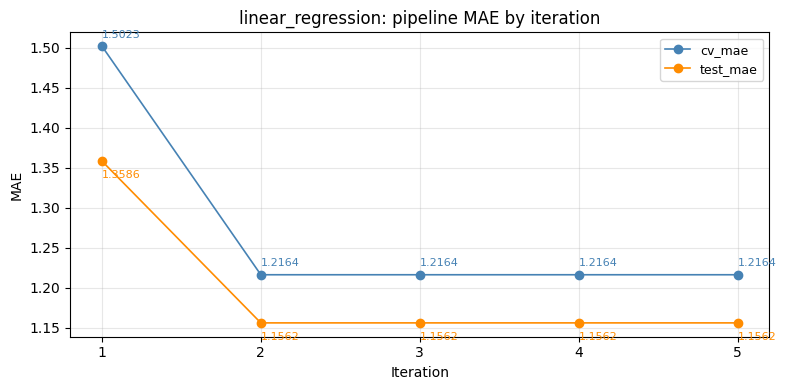

In [125]:
_name = 'linear_regression'
_iter = run_cutpoint_alternating_iterations(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_iterations=CUTPOINT_ALTERNATING_ITERATIONS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_iter['final_result'])
ordinal_best_params[_name] = _iter['final_params']
print_cutpoint_iteration_table(_name, _iter['history'])
if _iter['continued']:
    plot_cutpoint_iteration_mae(_iter['history'], _name)
print_tune_summary(_name, _iter['final_result'], _iter['final_params'])


#### `elasticnet_regression`

MSE with combined L1 (Lasso) and L2 (Ridge) penalties; helps when features are correlated (multicollinearity). **50 Optuna trials**; search ranges in `registry.get_search_space` (`alpha` log-uniform [1e-3, 10], `l1_ratio` [0, 1]).

[iter 1/5] elasticnet_regression
[iter 2/5] elasticnet_regression
[iter 3/5] elasticnet_regression
[iter 4/5] elasticnet_regression
[iter 5/5] elasticnet_regression
[iterations] elasticnet_regression


,iteration,cv_mae,test_mae
0,1,1.3150,1.3378
1,2,1.2160,1.1562
2,3,1.2160,1.1562
3,4,1.2160,1.1562
4,5,1.2160,1.1562


[ok] elasticnet_regression
  best_params: {'alpha': 0.8471801418819978, 'l1_ratio': 0.5986584841970366}
  cv_mae: 1.2160
  test_mae: 1.1562


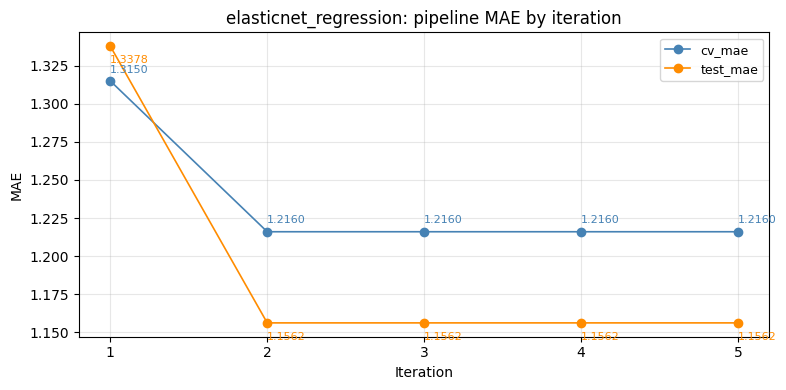

In [126]:
_name = 'elasticnet_regression'
_iter = run_cutpoint_alternating_iterations(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_iterations=CUTPOINT_ALTERNATING_ITERATIONS,
    n_trials=ELASTICNET_OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_iter['final_result'])
ordinal_best_params[_name] = _iter['final_params']
print_cutpoint_iteration_table(_name, _iter['history'])
if _iter['continued']:
    plot_cutpoint_iteration_mae(_iter['history'], _name)
print_tune_summary(_name, _iter['final_result'], _iter['final_params'])


#### `svr_regression`

RBF-kernel SVR with epsilon-insensitive loss (Huber-like, similar to MAE). Numeric features are scaled via `StandardScaler` in the pipeline preprocessor. **50 Optuna trials**; search ranges in `registry.get_search_space` (`C` log [0.01, 10], `epsilon` log [1e-3, 1], `gamma` scale/auto/float).


In [127]:
_name = 'svr_regression'
_iter = run_cutpoint_alternating_iterations(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_iterations=CUTPOINT_ALTERNATING_ITERATIONS,
    n_trials=SVR_OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_iter['final_result'])
ordinal_best_params[_name] = _iter['final_params']
print_cutpoint_iteration_table(_name, _iter['history'])
if _iter['continued']:
    plot_cutpoint_iteration_mae(_iter['history'], _name)
print_tune_summary(_name, _iter['final_result'], _iter['final_params'])


[iter 1/5] svr_regression
svr_regression: cutpoint values unchanged after iteration 1 (rint default); skipping iterations 2–5.
[iterations] svr_regression


,iteration,cv_mae,test_mae
0,1,1.2160,1.1562


[ok] svr_regression
  best_params: {'C': 0.039721107273819126, 'epsilon': 0.034890188454913866, 'gamma_mode': 'float', 'gamma': 0.00010547383621352031}
  cv_mae: 1.2160
  test_mae: 1.1562


#### `ordinal_rf`

[iter 1/5] ordinal_rf
[iter 2/5] ordinal_rf
[iter 3/5] ordinal_rf
[iter 4/5] ordinal_rf
[iter 5/5] ordinal_rf
[iterations] ordinal_rf


,iteration,cv_mae,test_mae
0,1,1.2943,1.3185
1,2,1.1814,1.1562
2,3,1.1810,1.1562
3,4,1.1810,1.1562
4,5,1.1810,1.1562


[ok] ordinal_rf
  best_params: {'n_estimators': 123, 'max_depth': 18, 'min_samples_leaf': 7}
  cv_mae: 1.1810
  test_mae: 1.1562


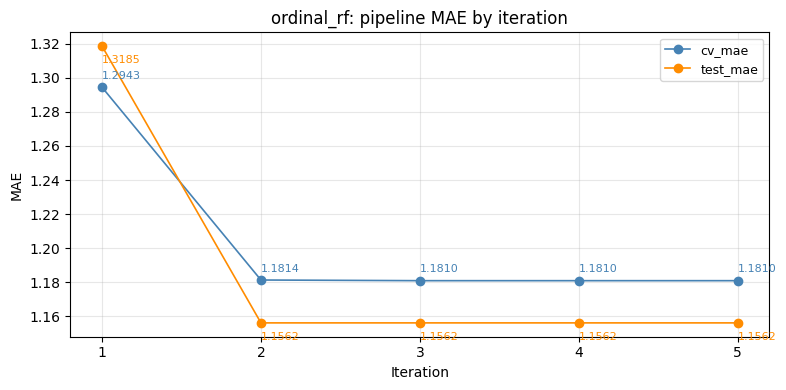

In [128]:
_name = 'ordinal_rf'
_iter = run_cutpoint_alternating_iterations(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_iterations=CUTPOINT_ALTERNATING_ITERATIONS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_iter['final_result'])
ordinal_best_params[_name] = _iter['final_params']
print_cutpoint_iteration_table(_name, _iter['history'])
if _iter['continued']:
    plot_cutpoint_iteration_mae(_iter['history'], _name)
print_tune_summary(_name, _iter['final_result'], _iter['final_params'])


#### `catboost_regressor`

In [129]:
_name = 'catboost_regressor'
_iter = run_cutpoint_alternating_iterations(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_iterations=CUTPOINT_ALTERNATING_ITERATIONS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_iter['final_result'])
ordinal_best_params[_name] = _iter['final_params']
print_cutpoint_iteration_table(_name, _iter['history'])
if _iter['continued']:
    plot_cutpoint_iteration_mae(_iter['history'], _name)
print_tune_summary(_name, _iter['final_result'], _iter['final_params'])


[iter 1/5] catboost_regressor


catboost_regressor: cutpoint values unchanged after iteration 1 (rint default); skipping iterations 2–5.
[iterations] catboost_regressor


,iteration,cv_mae,test_mae
0,1,1.2374,1.2173


[ok] catboost_regressor
  best_params: {'iterations': 100, 'depth': 5, 'learning_rate': 0.010038647625840051, 'l2_leaf_reg': 9.44962110862959}
  cv_mae: 1.2374
  test_mae: 1.2173


## 4. Results summary

Aggregates §2 baselines plus §3 tuned regression models. Results are grouped into **baseline** and **base** categories.

§3 regression models use an **up to 5-iteration** alternating tune + cutpoint loop (continues past iteration 1 only when OOF cutpoints update); this summary uses **final iteration** results only.

The next cell prints **CV** tables then **test** tables (baseline → base), sorted by `cv_mae` or `test_mae` respectively. Hyperparameters are printed in §3 tune cells only (not repeated here). Per-iteration MAE tables and plots are in §3.


In [130]:
# Merge baselines (§2) and base tuned models (§3).
# globals().get(...) allows partial notebook runs without NameError on skipped cells.

ordinal_results = globals().get('ordinal_results', [])
ordinal_best_params = globals().get('ordinal_best_params', {})

ran_tuned_models = sorted(ordinal_best_params)
print(f'Ran {len(ran_tuned_models)} tuned regression models: {ran_tuned_models}')

all_ordinal_results = ordinal_baseline_results + ordinal_results

category_summaries = collect_categorized_summaries(
    all_ordinal_results, include_best_params=False
)

print('CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    cv_cat, _ = category_summaries[category]
    if cv_cat.empty:
        continue
    print(f'  {category}')
    display(cv_cat)

print('Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    _, test_cat = category_summaries[category]
    if test_cat.empty:
        continue
    print(f'  {category}')
    display(test_cat)


Ran 5 tuned regression models: ['catboost_regressor', 'elasticnet_regression', 'linear_regression', 'ordinal_rf', 'svr_regression']
CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)
  baseline


,cv_mae,cv_rmse,cv_r2,cv_qwk,cv_mae_std
model,,,,,
lag1_fatigue,0.824015,1.315205,0.096947,0.546287,0.193110
expanding_mean,0.867974,1.198179,0.280799,0.495990,0.127344
global_mode,1.216046,1.554387,-0.200378,0.000000,0.243084
global_mean,1.348516,1.606173,-0.297646,0.000000,0.153930


  base


,cv_mae,cv_rmse,cv_r2,cv_qwk,cv_mae_std
model,,,,,
ordinal_rf,1.180994,1.524156,-0.153868,0.058380,0.239331
elasticnet_regression,1.216046,1.554387,-0.200378,0.000000,0.243084
svr_regression,1.216046,1.554387,-0.200378,0.000000,0.243084
linear_regression,1.216444,1.553984,-0.199641,0.006878,0.241497
catboost_regressor,1.237409,1.503457,-0.142358,0.093751,0.152617


Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)
  baseline


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
lag1_fatigue,0.950893,1.424175,0.104593,0.549449
expanding_mean,1.025298,1.336863,0.211017,0.422289
global_mode,1.156250,1.544479,-0.053072,0.000000
global_mean,1.406250,1.640721,-0.188402,0.000000


  base


,test_mae,test_rmse,test_r2,test_qwk
model,,,,
linear_regression,1.156250,1.544479,-0.053072,0.000000
elasticnet_regression,1.156250,1.544479,-0.053072,0.000000
svr_regression,1.156250,1.544479,-0.053072,0.000000
ordinal_rf,1.156250,1.542551,-0.050444,0.004019
catboost_regressor,1.217262,1.529472,-0.032707,0.058758


## 5. Diagnostic: identical test MAE?

This section explains *why* multiple rows in §4 can show identical `test_mae`.

### Purpose and method

**Purpose:** Sanity-check whether identical `test_mae` values in §4 reflect genuinely different models or the **same discrete test predictions**.

**Method:** Refit each §3 model on train/val with its final hyperparameters and cutpoints (from the last alternating iteration), predict on the held-out test set, then compare prediction vectors element-wise.

The code cell below calls `print_ordinal_test_prediction_diagnostic()` and prints three tables.

### Table 1 — Per-model summary (`[diagnostic] §3 test predictions`)

| Column | Meaning |
|--------|---------|
| `test_mae` | MAE on the held-out test set after refit with final §3 params and cutpoints (same metric as §4) |
| `n_unique_preds` | Count of distinct integer predictions on test rows; **1** = constant prediction for every test day |
| `cutpoints` | Cutpoints used in the final §3 iteration (`None` = rint default / no cutpoint-integrated wrapper, e.g. models that stopped after iteration 1) |

**What it tells us:** Models with the same MAE but different `n_unique_preds` or cutpoints may still differ in predictions. Models with `n_unique_preds = 1` predict a single fatigue level for all test rows (often the training-set mode).

### Table 2 — Pairwise match matrix (lower triangle; green / red)

- **Rows/columns:** model names; cell `(row, col)` compares the row model’s test vector vs the column model’s test vector.
- **Green “Same”:** every test-row prediction is identical between the two models.
- **Red “Different”:** at least one test row differs.

**What it tells us:** If several models share the same `test_mae` and are all green vs each other, they make **identical** test predictions—ranking by MAE in §4 does not distinguish them. Different cutpoints can still yield the same final discrete vector (e.g. all continuous scores map to the same class).

### Table 3 — vs `global_mode` (`matches_global_mode`)

- Compares each model’s test vector to the **`global_mode` baseline** (constant prediction = most frequent fatigue level in train/val).
- **Green “Same as global_mode”:** model outputs exactly the global-mode vector on test (matching baseline MAE is expected).
- The printed `global_mode test_mae` line is the baseline MAE for reference.

**What it tells us:** If tuned models match global mode, the regression + cutpoint pipeline has collapsed to the simple baseline on test—features and tuning did not produce meaningfully different predictions despite possibly different CV paths or cutpoints.


In [131]:
print_ordinal_test_prediction_diagnostic(
    bundle,
    ordinal_results,
    ordinal_best_params,
    ORDINAL_MODELS,
)

[diagnostic] §3 test predictions


,test_mae,n_unique_preds,cutpoints
model,,,
linear_regression,1.156250,1,"[-0.9, -0.8, -0.3, 4.5, 4.6]"
elasticnet_regression,1.156250,1,"[0.5, 1.5, 2.1, 3.5, 4.5]"
svr_regression,1.156250,1,None
ordinal_rf,1.156250,2,"[0.3, 0.8, 1.0, 4.1, 4.5]"
catboost_regressor,1.217262,2,None


Pairwise identical test predictions (lower triangle; green = same vector)


,linear_regression,elasticnet_regression,svr_regression,ordinal_rf,catboost_regressor
linear_regression,Same,nan,nan,nan,nan
elasticnet_regression,Same,Same,nan,nan,nan
svr_regression,Same,Same,Same,nan,nan
ordinal_rf,Different,Different,Different,Same,nan
catboost_regressor,Different,Different,Different,Different,Same


global_mode test_mae = 1.1562 (green = same test vector as global_mode)


,matches_global_mode
linear_regression,Same as global_mode
elasticnet_regression,Same as global_mode
svr_regression,Same as global_mode
ordinal_rf,Different from global_mode
catboost_regressor,Different from global_mode


## 6. ordinal_rf feature importance

How important is each **base** feature for the tuned `ordinal_rf` from §3? Requires §1 and the §3 `ordinal_rf` cell (`ordinal_best_params['ordinal_rf']`).

Two complementary views:

- **§6.1 Gini importances** — mean decrease in impurity from the fitted random forest (fast; relative split contribution).
- **§6.2 Leave-one-out CV ablation** — refit without each feature under GroupKFold CV with fixed §3 hyperparameters; higher `cv_mae_increase_vs_all` means removing that feature hurts CV more.

### 6.1 Gini importances

Refits `ordinal_rf` on train/val with §3 `best_params`, then reports sklearn **Gini / MDI** importances from the inner `RandomForestRegressor`. Same table + bar chart pattern as [`other features.ipynb`](other%20features.ipynb) §5.

,feature,importance
0,filtered_demographic_vo2_max,0.201066
1,age,0.171058
2,age_of_first_menarche,0.087862
3,daily_hrv,0.077910
4,daily_glucose,0.055113
5,menstrual_health_literacy_num,0.053235
6,estrogen_smooth,0.045142
7,lh_smooth,0.041517
8,lightly_activity,0.036695
9,calories_sum,0.034788


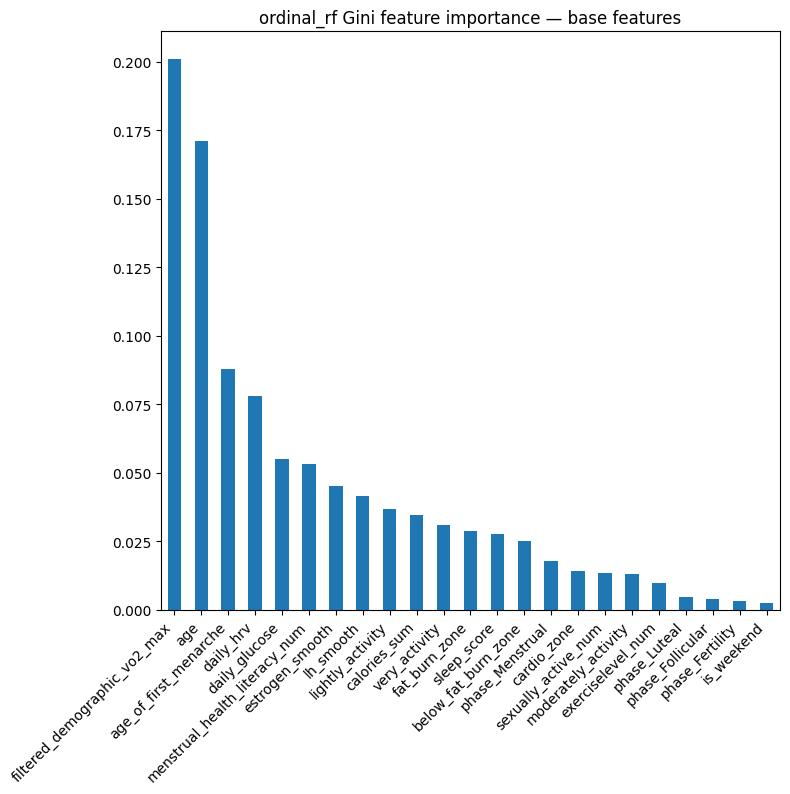

In [132]:
print_ordinal_rf_gini_importance(
    bundle,
    ordinal_best_params,
    ORDINAL_MODELS,
)

### 6.2 Leave-one-out CV ablation

For each feature column, drops that column and re-runs **GroupKFold CV** with the same §3 hyperparameters. Same interpretation as [`history feature engineering.ipynb`](history%20feature%20engineering.ipynb): higher `cv_mae_increase_vs_all` = more important. Slower than §6.1 (one CV run per feature).

All-23-feature CV MAE: 1.3435
Removing each feature — higher cv_mae_increase_vs_all = more important:


,feature,cv_mae_without_feature,cv_mae_increase_vs_all
0,age_of_first_menarche,1.364123,0.020672
1,filtered_demographic_vo2_max,1.358581,0.015130
2,sleep_score,1.351802,0.008352
3,sexually_active_num,1.343591,0.000140
4,cardio_zone,1.342448,-0.001003
5,phase_Fertility,1.342356,-0.001095
6,lightly_activity,1.342067,-0.001384
7,phase_Follicular,1.341175,-0.002276
8,fat_burn_zone,1.341121,-0.002329
9,calories_sum,1.340819,-0.002632


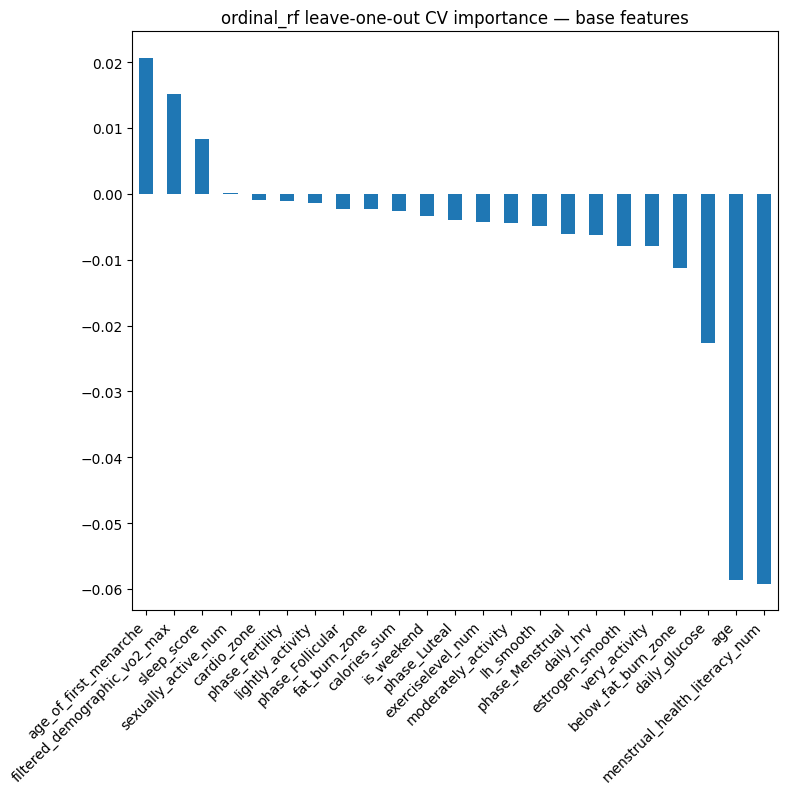

(1.3434504058595276,
                           feature  cv_mae_without_feature  \
 0           age_of_first_menarche                1.364123   
 1    filtered_demographic_vo2_max                1.358581   
 2                     sleep_score                1.351802   
 3             sexually_active_num                1.343591   
 4                     cardio_zone                1.342448   
 5                 phase_Fertility                1.342356   
 6                lightly_activity                1.342067   
 7                phase_Follicular                1.341175   
 8                   fat_burn_zone                1.341121   
 9                    calories_sum                1.340819   
 10                     is_weekend                1.340082   
 11                   phase_Luteal                1.339405   
 12              exerciselevel_num                1.339133   
 13            moderately_activity                1.338951   
 14                      lh_smooth               

In [133]:
print_ordinal_rf_ablation_importance(
    bundle,
    ordinal_best_params,
    ORDINAL_MODELS,
)